# CF Models — PEP725 Fruit Trees

Fits species-specific process-based chill-forcing (CF) models on the
`PEP725_fruit_trees` dataset (9 species, target `BBCH_60` = first flowering)
using a **temporal train/test split** and evaluates them across species.

| Model | Chilling | Forcing |
|---|---|---|
| `GDDModel` | — (heat from season start) | GDU |
| `UtahGDDModel` | Utah chill units | GDU after chill gate |
| `ChillingDaysGDDModel` | Days ≤ *t_chill* | GDU after chill gate |
| `DynamicGDDModel` | Dynamic chill portions | GDU after chill gate |

Each model is fitted independently per species. Results are compared in a
species × model summary heatmap.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from pysephone.constants import KEY_FEATURES
from pysephone.dataset.dataset import Dataset
from pysephone.dataset.util.calendar import Calendar
from pysephone.dataset.util.openmeteo import OpenMeteoFeatures
from pysephone.evaluation.regression import SingleTargetRegression
from pysephone.models.gdd import GDDModel
from pysephone.models.cf import (
    UtahGDDModel,
    ChillingDaysGDDModel,
    DynamicGDDModel,
)
from pysephone.models.util.func_phenology import (
    func_utah_chill,
    func_chilling_days,
    func_dynamic_chill_daily,
)

In [2]:
# ── Configuration ────────────────────────────────────────────────────────────
DATASET_KEY  = 'PEP725_fruit_trees'
OBS_KEY      = 'BBCH_60'        # first flowering
CUTOFF       = 2006             # train < CUTOFF, test >= CUTOFF
OPT_MAX_TIME = 60.0             # seconds per optimisation phase per model

OPT_KW = dict(opt_max_time=OPT_MAX_TIME)

MODEL_SPECS = [
    (
        'GDD',
        GDDModel,
        dict(threshold=200.0, t_base=4.0, **OPT_KW),
    ),
    (
        'Utah+GDD',
        UtahGDDModel,
        dict(threshold_c=50.0, threshold_f=200.0, t_base=4.0, **OPT_KW),
    ),
    (
        'ChillingDays+GDD',
        ChillingDaysGDDModel,
        dict(threshold_c=50.0, threshold_f=200.0, **OPT_KW),
    ),
    (
        'Dynamic+GDD',
        DynamicGDDModel,
        dict(threshold_c=50.0, threshold_f=200.0, t_base=4.0, **OPT_KW),
    ),
]

## 1. Load dataset

A single full-dataset load is used; per-species subsets are obtained by
`select_species()`, which avoids redundant downloads.

In [ ]:
from pysephone.dataset.util.feature_cache import FeatureCache

DATA_KEYS = ['temperature_2m_mean']
cal    = Calendar(default_start='10-01', default_length=365)
_cache = FeatureCache.load(FeatureCache.default_path(DATASET_KEY, DATA_KEYS))
ds_all = Dataset.load(DATASET_KEY, calendar=cal, feature_providers=[_cache])

obs          = ds_all.observations
id_to_name   = obs.species_names
species_keys = sorted(obs.species)

print(f'Loaded {DATASET_KEY}')
print(f'  {len(ds_all):,} observations | {len(obs.locations):,} locations'
      f' | {len(obs.years)} years | {len(species_keys)} species')
print()

rows = []
for key in species_keys:
    name = id_to_name.get(key, str(key))
    ds_sp = ds_all.select_species([key])
    years = sorted(ds_sp.years)
    rows.append(dict(species=name, n=len(ds_sp),
                     years=f'{years[0]}–{years[-1]}',
                     locations=len(ds_sp.locations)))

df_overview = pd.DataFrame(rows).set_index('species')
print(df_overview)


## 2. Temporal split

Train on years before `CUTOFF`, test on years from `CUTOFF` onwards.
We build one dict of per-species Dataset pairs.

In [4]:
def temporal_split(ds, cutoff):
    years = sorted(ds.years)
    trn = [y for y in years if y < cutoff]
    tst = [y for y in years if y >= cutoff]
    return ds.select_years(trn), ds.select_years(tst)


# Build per-species dataset dict
species_datasets = {}  # name -> (ds_trn, ds_tst)

print(f'Temporal split: train < {CUTOFF}, test >= {CUTOFF}')
print(f'{"Species":40s}  {"N train":>8s}  {"N test":>8s}')
print('-' * 60)

for key in species_keys:
    name   = id_to_name.get(key, str(key))
    ds_sp  = ds_all.select_species([key])
    ds_trn, ds_tst = temporal_split(ds_sp, CUTOFF)
    species_datasets[name] = (ds_trn, ds_tst)
    print(f'{name:40s}  {len(ds_trn):>8d}  {len(ds_tst):>8d}')

Temporal split: train < 2006, test >= 2006
Species                                    N train    N test
------------------------------------------------------------
Corylus avellana                              6749      3181
Prunus spinosa                                5594      2743
Prunus persica                                 979        14
Prunus armeniaca                                15       175
Malus x domestica                             4154      2607
Prunus avium                                  4768      2797
Prunus domestica                              2420       684
Pyrus communis                                 979      2305
Prunus amygdalis                                97        56


## 3. Fit models

Each of the four models is fitted independently per species on the training split.

In [5]:
target_fn = lambda s: s['observations'][OBS_KEY]

fitted = {}  # {species_name: {model_name: model}}

for sp_name, (ds_trn, _) in species_datasets.items():
    fitted[sp_name] = {}
    for model_name, cls, kwargs in MODEL_SPECS:
        print(f'Fitting {model_name:20s} on {sp_name}...', end=' ', flush=True)
        model, _ = cls.fit(
            target_fn=target_fn,
            dataset=ds_trn,
            model_kwargs=dict(kwargs),
        )
        fitted[sp_name][model_name] = model
        print(f'done  params: {model.params}')

Fitting GDD                  on Corylus avellana... done  params: {'threshold': 666.024809217367, 't_base': 0.12206538702611783}
Fitting Utah+GDD             on Corylus avellana... done  params: {'th_c': 50.47029448166051, 'th_f': 133.17903374013147, 't_base': 0.15019447719046197}
Fitting ChillingDays+GDD     on Corylus avellana... done  params: {'th_c': 88.27128829307168, 'th_f': 81.76023457210759, 't_chill': 12.263302474258824, 't_base': 0.4637794472715811}
Fitting Dynamic+GDD          on Corylus avellana... done  params: {'th_c': 25.000000000000004, 'th_f': 1000.0, 't_base': 5.0, 'amplitude': 7.749999999999999}
Fitting GDD                  on Prunus spinosa... done  params: {'threshold': 862.5188037327831, 't_base': 1.1361598906530728}
Fitting Utah+GDD             on Prunus spinosa... done  params: {'th_c': 49.41904582665964, 'th_f': 330.0090145916794, 't_base': 1.7496087020416065}
Fitting ChillingDays+GDD     on Prunus spinosa... done  params: {'th_c': 102.29098012072984, 'th_f': 3

## 4. Evaluate

In [6]:
results = {}  # {species_name: {model_name: SingleTargetRegression}}

for sp_name, (ds_trn, ds_tst) in species_datasets.items():
    results[sp_name] = {}
    sp_slug = sp_name.lower().replace(' ', '_').replace('.', '')
    for model_name, model in fitted[sp_name].items():
        run_name = f'{model_name.lower().replace("+", "_")}_{sp_slug}'
        results[sp_name][model_name] = SingleTargetRegression.run(
            model=model,
            dataset_train=ds_trn,
            dataset_test=ds_tst,
            target_fn=target_fn,
            run_name=run_name,
        )

### 4a. Metrics table

In [7]:
rows = []
for sp_name, model_results in results.items():
    for model_name, result in model_results.items():
        m = result.compute_metrics()
        for split in ('train', 'test'):
            if not m[split]:
                continue
            rows.append({
                'Species': sp_name,
                'Model':   model_name,
                'Split':   split,
                'N':       int(m[split]['n']),
                'RMSE':    round(m[split]['rmse'], 2),
                'MAE':     round(m[split]['mae'], 2),
                'Bias':    round(m[split]['bias'], 2),
                'R²':      round(m[split]['r2'], 3),
            })

df_metrics = pd.DataFrame(rows).set_index(['Species', 'Model', 'Split'])
with pd.option_context('display.max_rows', 200):
    display(df_metrics)

N    RMSE     MAE    Bias  \
Species           Model            Split                                 
Corylus avellana  GDD              train  6749  123.54   72.50   65.24   
                                   test   3181  127.13   72.74   65.14   
                  Utah+GDD         train  6749   59.04   28.66   14.58   
                                   test   3181   24.39   19.26   10.53   
                  ChillingDays+GDD train  6749   17.20   11.52   -0.38   
                                   test   3181   19.46   14.53    8.95   
                  Dynamic+GDD      train  6749  149.93  148.30  148.30   
                                   test   3181  143.04  141.19  141.19   
Prunus spinosa    GDD              train  5594   38.86   24.72   10.79   
                                   test   2743   30.31   20.91   11.83   
                  Utah+GDD         train  5594   15.76   12.03    4.34   
                                   test   2743   13.04   10.32    7.80   
                  ChillingDays+GDD train  5594    9.47    6.96    0.50   
                                   test   2743    8.59    6.44    3.60   
                  Dynamic+GDD      train  5594   99.45   98.23   98.23   
                                   test   2743   91.68   90.80   90.80   
Prunus persica    GDD              train   979   32.21   13.92    5.72   
                                   test     14  219.53  192.43  177.71   
                  Utah+GDD         train   979   10.40    6.17   -0.11   
                                   test     14  118.87   75.93   72.50   
                  ChillingDays+GDD train   979    6.98    4.61   -0.11   
                                   test     14  106.27   67.07   67.07   
                  Dynamic+GDD      train   979   12.41    7.34    0.53   
                                   test     14  131.24   92.50   92.36   
Prunus armeniaca  GDD              train    15   58.65   53.67   10.60   
                                   test    175   57.49   52.04   48.05   
                  Utah+GDD         train    15   14.72   12.07   -1.40   
                                   test    175   16.64   11.00    6.36   
                  ChillingDays+GDD train    15    8.00    6.20   -0.20   
                                   test    175   25.84   11.82    3.10   
                  Dynamic+GDD      train    15    8.35    6.33    2.07   
                                   test    175   14.81    9.74    6.30   
Malus x domestica GDD              train  4154   29.66   17.04    7.16   
                                   test   2607   23.98   16.42    1.24   
                  Utah+GDD         train  4154   14.11    8.91    1.96   
                                   test   2607    9.64    7.28    1.50   
                  ChillingDays+GDD train  4154    8.11    5.43    0.61   
                                   test   2607    6.48    4.76    1.59   
                  Dynamic+GDD      train  4154   27.35   23.54   23.54   
                                   test   2607   24.95   22.79   22.79   
Prunus avium      GDD              train  4768   33.88   19.37   10.02   
                                   test   2797   36.22   22.24    1.04   
                  Utah+GDD         train  4768   14.43   10.55    3.48   
                                   test   2797   14.45   10.37    2.57   
                  ChillingDays+GDD train  4768    7.33    5.25    0.67   
                                   test   2797    9.14    4.97    1.46   
                  Dynamic+GDD      train  4768   35.49   33.31   33.31   
                                   test   2797   36.18   33.50   33.50   
Prunus domestica  GDD              train  2420   37.18   19.57   10.33   
                                   test    684   56.76   29.50   12.15   
                  Utah+GDD         train  2420   11.47    8.07    1.11   
                                   test    684   16.47    9.67   -0.10   
                  ChillingDays+GDD train  2420   

### 4b. Summary heatmaps (test split)

RMSE and R² for the test split, one heatmap per metric.

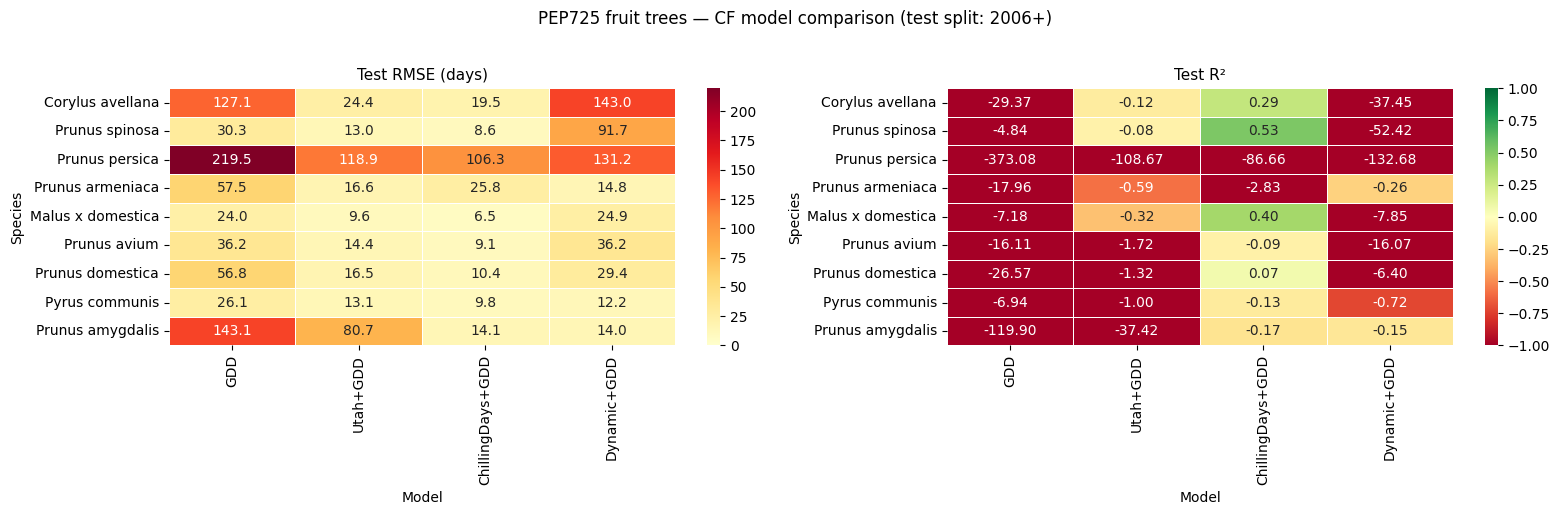

In [8]:
_STYLE = {
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         False,
    'font.size':         10,
    'axes.titlesize':    11,
    'axes.labelsize':    10,
}

model_names = [n for n, _, _ in MODEL_SPECS]
sp_names    = list(species_datasets.keys())


def _heatmap_metric(metric_key, cmap, fmt, title, vmin=None, vmax=None, ax=None):
    mat = pd.DataFrame(index=sp_names, columns=model_names, dtype=float)
    for sp in sp_names:
        for mname in model_names:
            m = results[sp][mname].compute_metrics()['test']
            mat.loc[sp, mname] = m.get(metric_key, float('nan'))
    if ax is None:
        _, ax = plt.subplots(figsize=(8, 5))
    sns.heatmap(
        mat.astype(float), annot=True, fmt=fmt,
        cmap=cmap, vmin=vmin, vmax=vmax,
        linewidths=0.4, ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel('Model')
    ax.set_ylabel('Species')
    ax.tick_params(axis='y', rotation=0)
    return mat


with plt.rc_context(_STYLE):
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    _heatmap_metric('rmse', 'YlOrRd', '.1f', 'Test RMSE (days)', vmin=0, ax=axes[0])
    _heatmap_metric('r2',   'RdYlGn', '.2f', 'Test R²',          vmin=-1, vmax=1, ax=axes[1])

    fig.suptitle(f'PEP725 fruit trees — CF model comparison (test split: {CUTOFF}+)', y=1.02)
    plt.tight_layout()
    plt.show()

### 4c. MAE heatmap (test split)

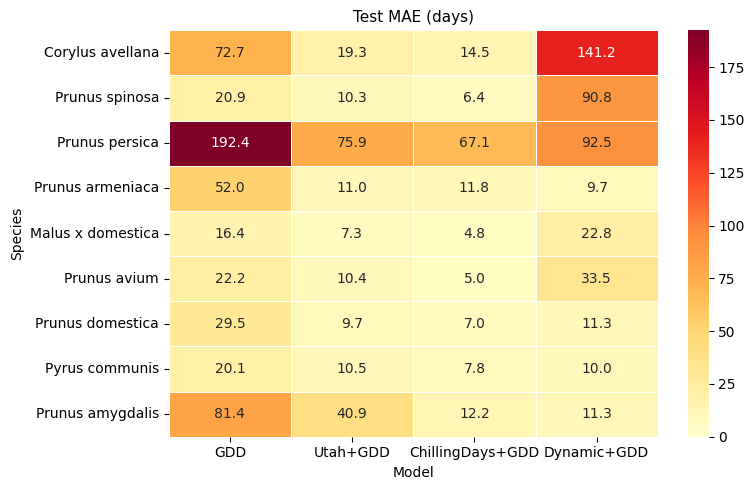

In [9]:
with plt.rc_context(_STYLE):
    fig, ax = plt.subplots(figsize=(8, 5))
    _heatmap_metric('mae', 'YlOrRd', '.1f', 'Test MAE (days)', vmin=0, ax=ax)
    plt.tight_layout()
    plt.show()

### 4d. Train vs test RMSE — model gain from chilling

Bar chart comparing RMSE on the test split across all species and models,
grouped by model. Shows whether CF models outperform the plain GDD baseline.

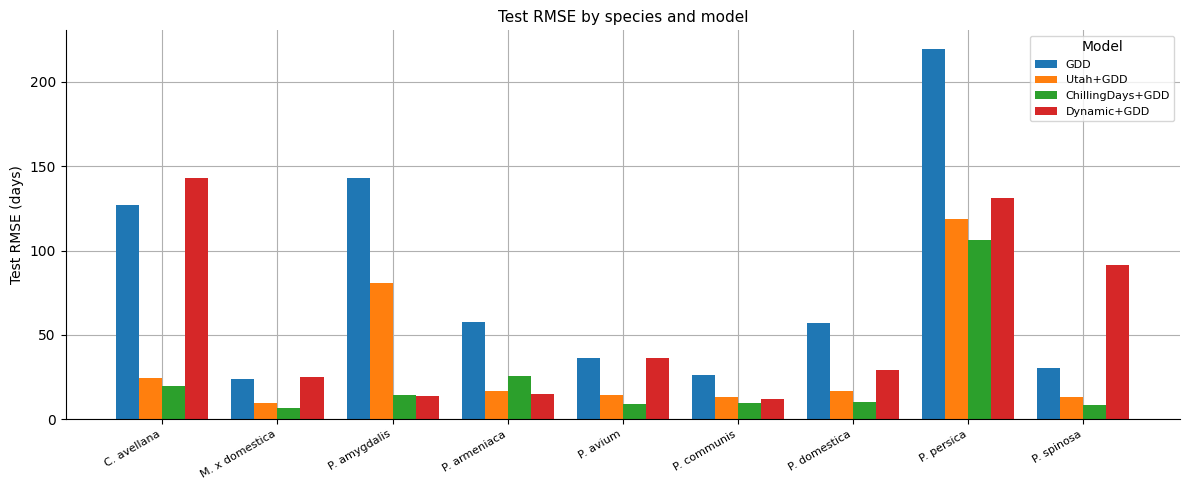

In [10]:
df_test = df_metrics.xs('test', level='Split').reset_index()

# Abbreviate species names
def abbrev(name):
    parts = name.split()
    return f'{parts[0][0]}. {" ".join(parts[1:])}' if len(parts) > 1 else name

df_test['Species'] = df_test['Species'].map(abbrev)

with plt.rc_context({**_STYLE, 'axes.grid': True, 'axes.axisbelow': True}):
    fig, ax = plt.subplots(figsize=(12, 5))

    sp_order = sorted(df_test['Species'].unique())
    x = np.arange(len(sp_order))
    w = 0.2
    colors = sns.color_palette('tab10', len(model_names))

    for i, mname in enumerate(model_names):
        sub = df_test[df_test['Model'] == mname].set_index('Species').reindex(sp_order)
        ax.bar(x + i * w, sub['RMSE'], width=w, label=mname, color=colors[i])

    ax.set_xticks(x + w * 1.5)
    ax.set_xticklabels(sp_order, rotation=30, ha='right', fontsize=8)
    ax.set_ylabel('Test RMSE (days)')
    ax.set_title('Test RMSE by species and model')
    ax.legend(title='Model', fontsize=8)
    plt.tight_layout()
    plt.show()

## 5. Fitted parameters

Display the fitted parameters for each model and species.

In [11]:
for model_name, _, _ in MODEL_SPECS:
    rows = []
    for sp_name in sp_names:
        m = fitted[sp_name][model_name]
        row = {'Species': sp_name}
        row.update({k: round(v, 3) for k, v in m.params.items()})
        rows.append(row)
    df_params = pd.DataFrame(rows).set_index('Species')
    print(f'\n{model_name}')
    display(df_params)


GDD


,threshold,t_base
Species,,
Corylus avellana,666.025,0.122
Prunus spinosa,862.519,1.136
Prunus persica,882.647,0.560
Prunus armeniaca,1426.340,0.013
Malus x domestica,1086.437,0.000
Prunus avium,912.148,0.334
Prunus domestica,840.102,1.007
Pyrus communis,1016.942,0.770
Prunus amygdalis,1229.602,0.151



Utah+GDD


,th_c,th_f,t_base
Species,,,
Corylus avellana,50.470,133.179,0.150
Prunus spinosa,49.419,330.009,1.750
Prunus persica,49.336,113.744,5.024
Prunus armeniaca,33.862,115.840,4.494
Malus x domestica,35.152,320.429,3.277
Prunus avium,42.199,317.686,2.053
Prunus domestica,33.639,108.387,6.108
Pyrus communis,14.092,333.377,3.874
Prunus amygdalis,29.691,118.667,2.662



ChillingDays+GDD


,th_c,th_f,t_chill,t_base
Species,,,,
Corylus avellana,88.271,81.760,12.263,0.464
Prunus spinosa,102.291,329.568,13.247,0.433
Prunus persica,109.730,315.952,12.985,0.496
Prunus armeniaca,98.851,107.985,12.510,3.152
Malus x domestica,115.337,330.820,14.911,2.098
Prunus avium,133.218,313.759,14.121,0.197
Prunus domestica,129.627,333.653,14.799,0.556
Pyrus communis,80.029,325.474,14.149,2.349
Prunus amygdalis,77.761,111.171,14.117,1.261



Dynamic+GDD


,th_c,th_f,t_base,amplitude
Species,,,,
Corylus avellana,25.000,1000.000,5.000,7.750
Prunus spinosa,25.000,1000.000,5.000,7.750
Prunus persica,25.413,336.845,1.671,12.565
Prunus armeniaca,74.938,109.879,3.882,2.813
Malus x domestica,75.000,333.333,5.000,7.750
Prunus avium,75.000,333.333,5.000,7.750
Prunus domestica,71.060,157.113,4.656,7.506
Pyrus communis,25.120,444.236,1.626,7.902
Prunus amygdalis,32.432,259.259,0.490,5.253


## 6. Scatter plots — best model per species

Predicted vs. observed DOY (test split) for the model with lowest test RMSE
per species.

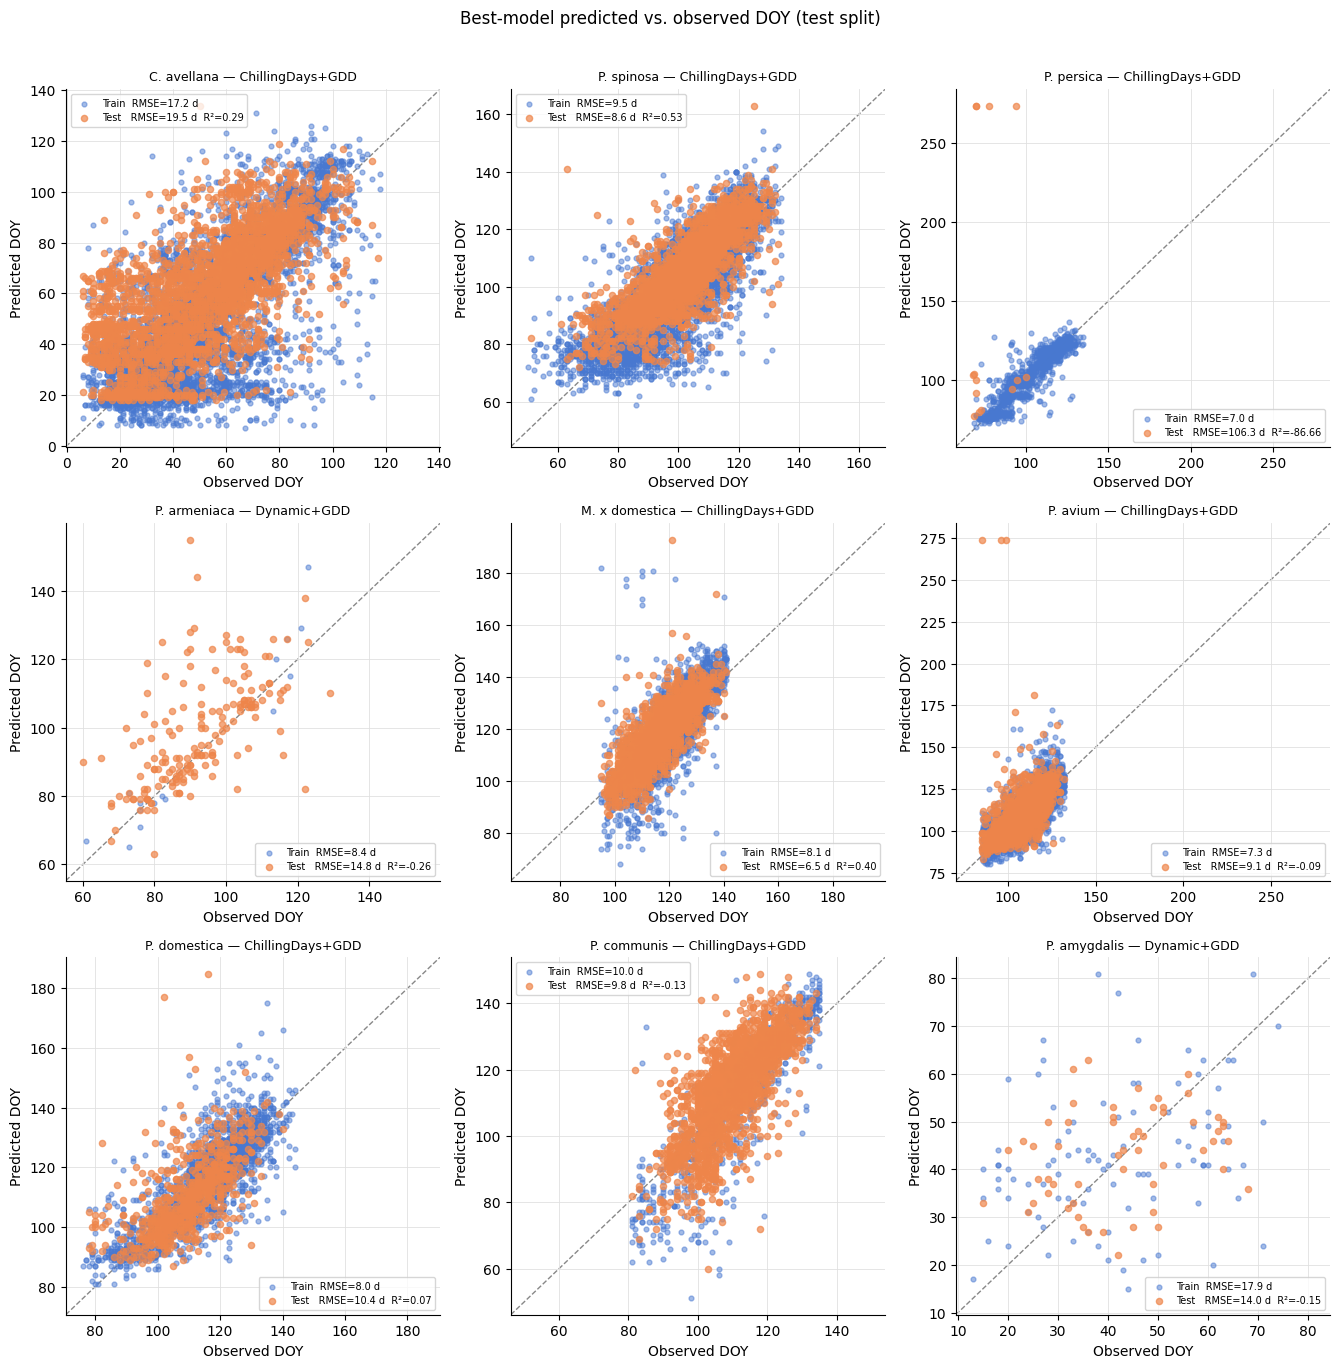

In [12]:
_COLOUR_TRAIN = '#4878d0'
_COLOUR_TEST  = '#ee854a'


def _scatter_ax(ax, result, title):
    m_tr = result.compute_metrics()['train']
    m_te = result.compute_metrics()['test']

    all_doys = pd.concat([
        result.df_train[['predicted_doy', 'observed_doy']],
        result.df_test[['predicted_doy', 'observed_doy']],
    ])
    lo, hi = all_doys.min().min(), all_doys.max().max()
    pad = (hi - lo) * 0.05
    lim = (lo - pad, hi + pad)

    ax.plot(lim, lim, color='#888', linewidth=1, linestyle='--', zorder=0)

    ax.scatter(
        result.df_train['observed_doy'], result.df_train['predicted_doy'],
        s=12, alpha=0.5, color=_COLOUR_TRAIN, zorder=2,
        label=f"Train  RMSE={m_tr['rmse']:.1f} d",
    )
    ax.scatter(
        result.df_test['observed_doy'], result.df_test['predicted_doy'],
        s=20, alpha=0.7, color=_COLOUR_TEST, zorder=3,
        label=f"Test   RMSE={m_te['rmse']:.1f} d  R²={m_te['r2']:.2f}",
    )
    ax.set_xlim(lim)
    ax.set_ylim(lim)
    ax.set_xlabel('Observed DOY')
    ax.set_ylabel('Predicted DOY')
    ax.set_title(title, fontsize=9)
    ax.legend(fontsize=7)


with plt.rc_context({**_STYLE, 'axes.grid': True, 'grid.color': '#e0e0e0',
                     'grid.linewidth': 0.6, 'axes.axisbelow': True}):
    # Find best model per species (lowest test RMSE)
    best = {}
    for sp in sp_names:
        best_rmse, best_name = float('inf'), None
        for mname in model_names:
            te = results[sp][mname].compute_metrics()['test']
            if te and te['rmse'] < best_rmse:
                best_rmse, best_name = te['rmse'], mname
        best[sp] = best_name

    ncols = 3
    nrows = int(np.ceil(len(sp_names) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4.5, nrows * 4.5))
    axes = axes.flatten()

    for i, sp in enumerate(sp_names):
        mname  = best[sp]
        result = results[sp][mname]
        _scatter_ax(axes[i], result, f'{abbrev(sp)} — {mname}')

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle('Best-model predicted vs. observed DOY (test split)', y=1.01)
    plt.tight_layout()
    plt.show()

## 7. Model response on a representative sample

Visualise the chill and forcing accumulation trajectories for one sample
per species (first available test year), using the best-performing model.

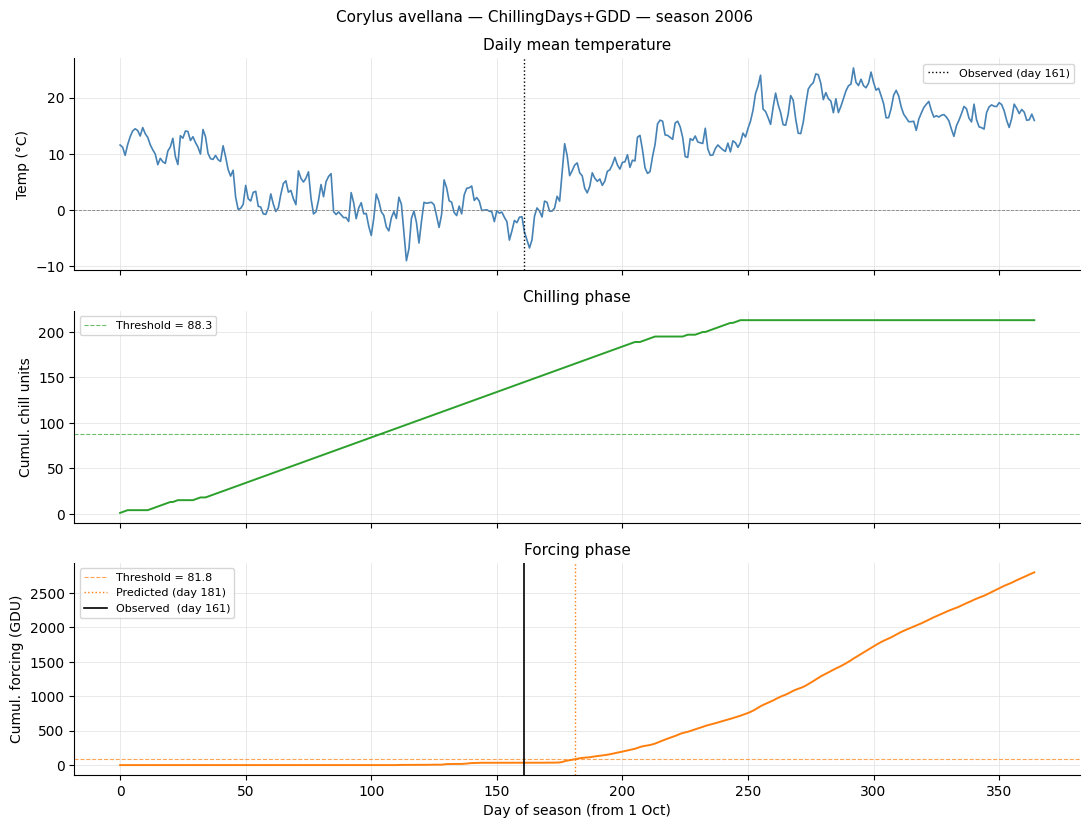

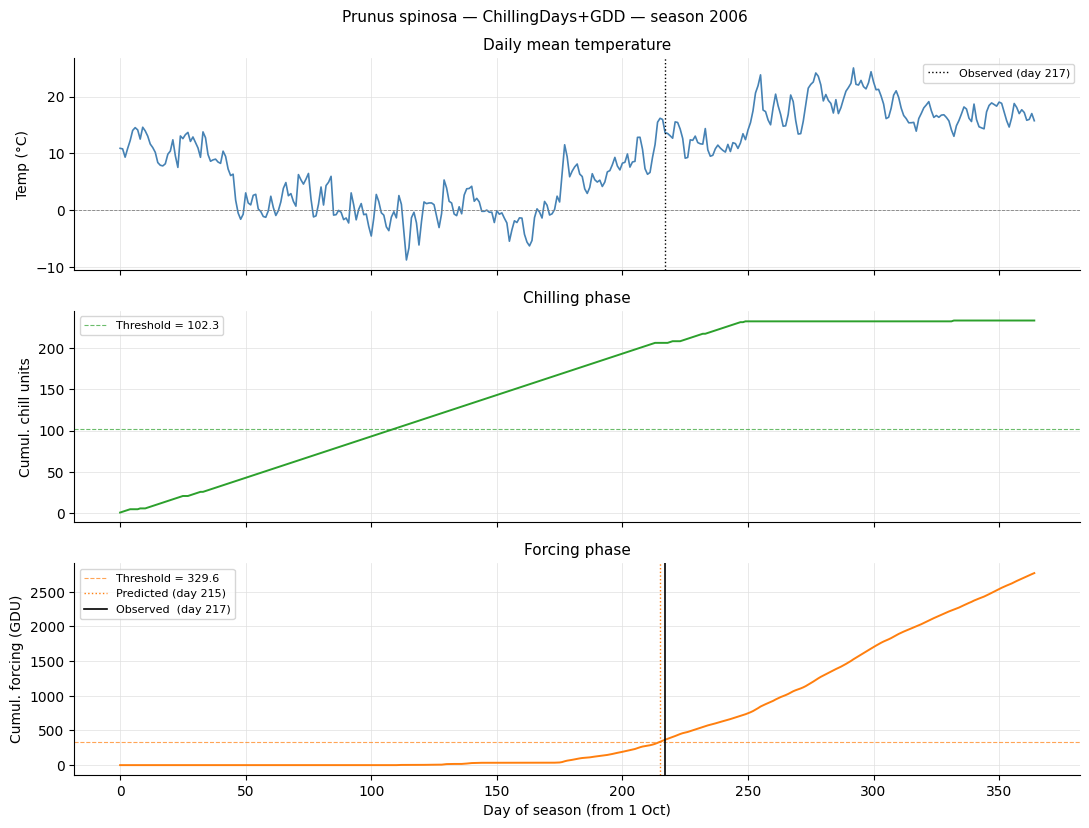

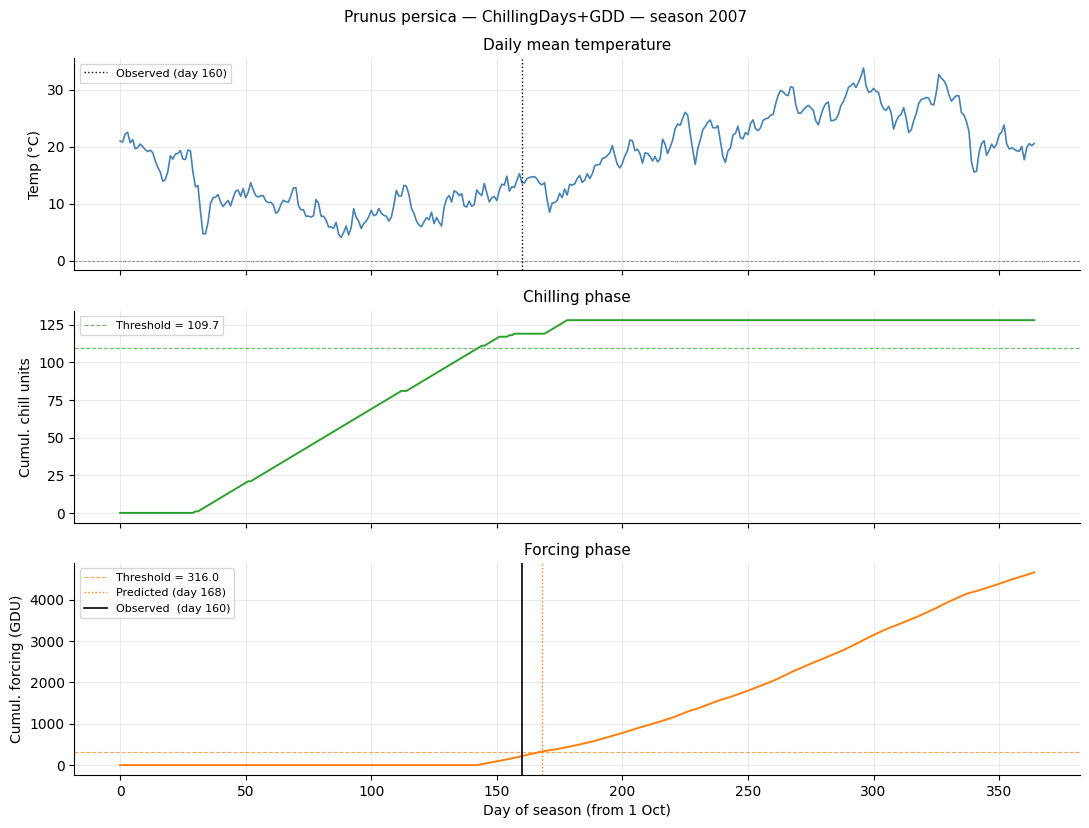

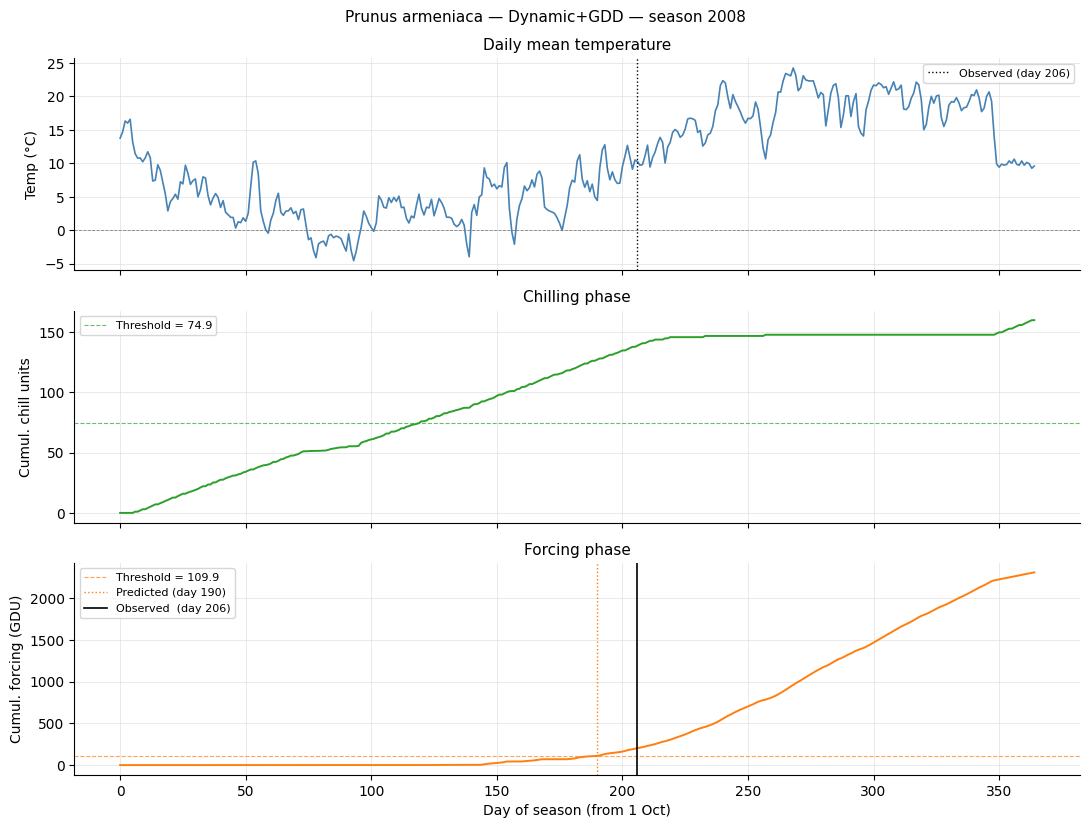

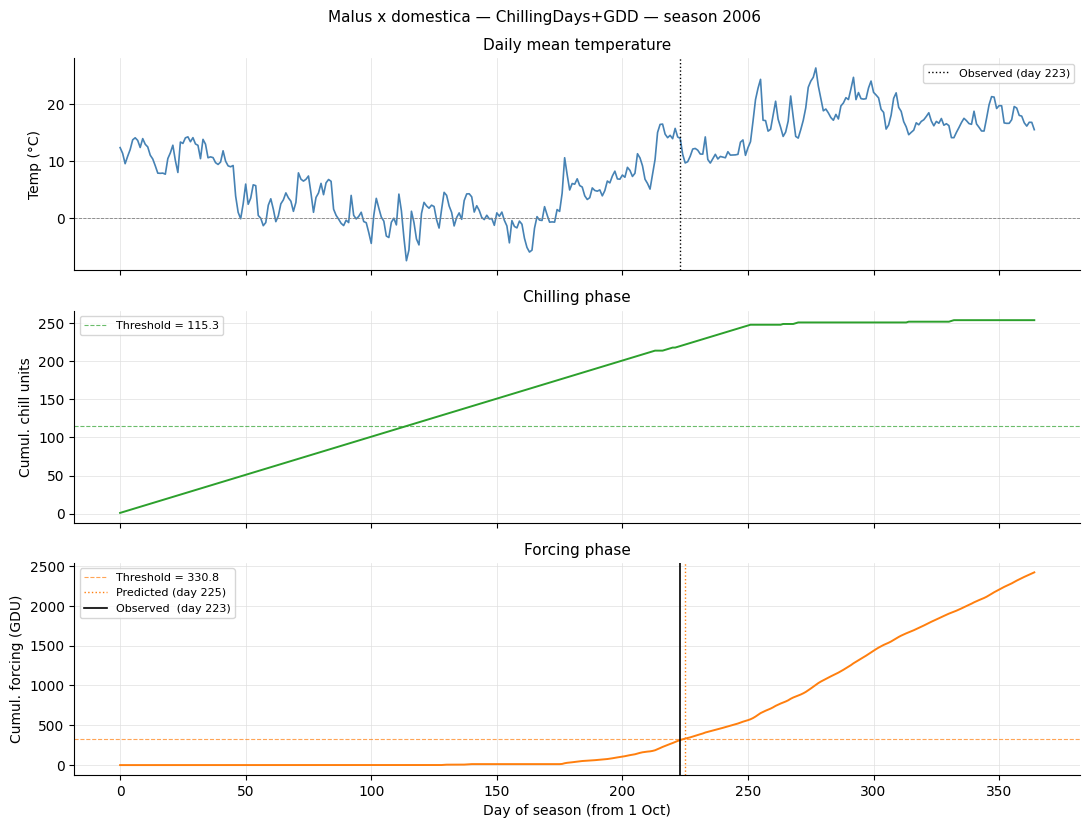

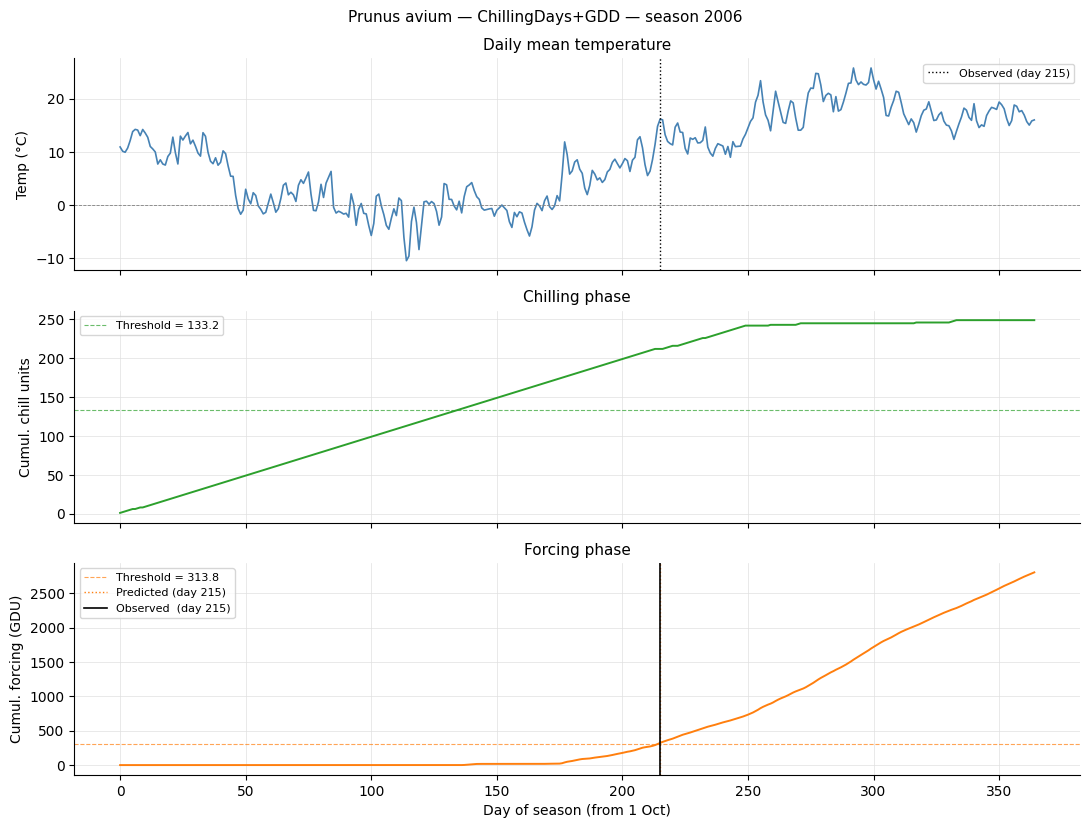

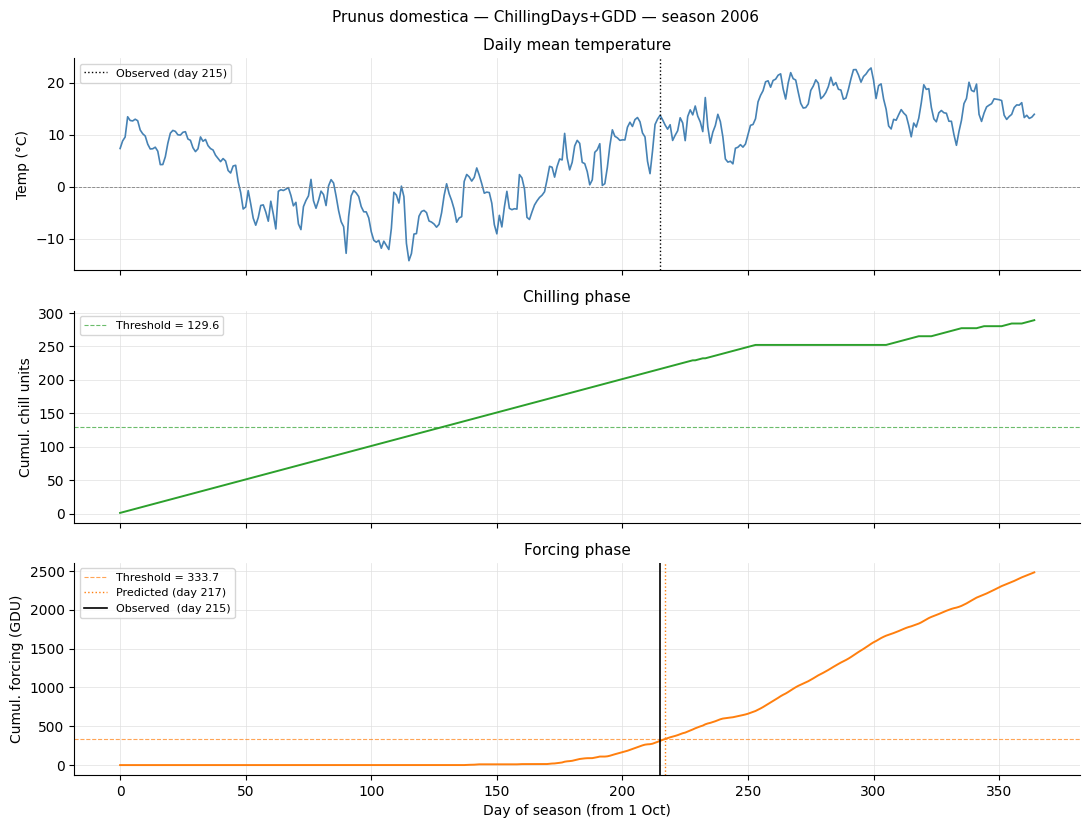

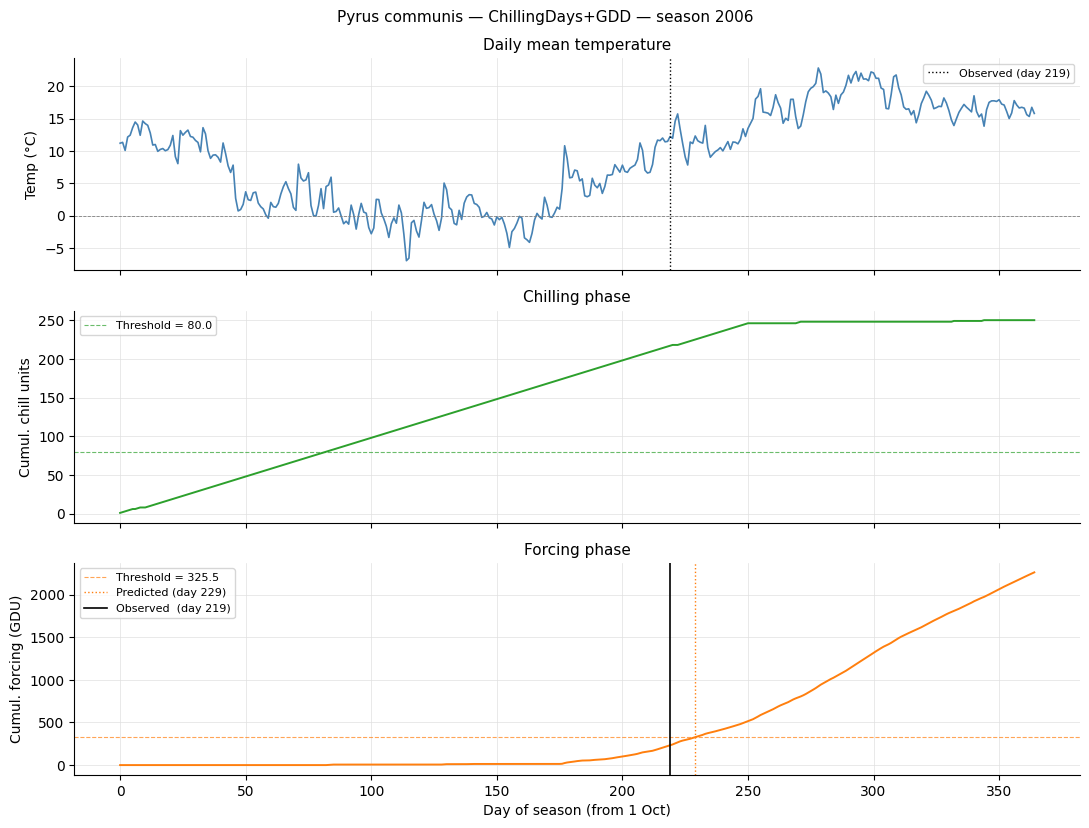

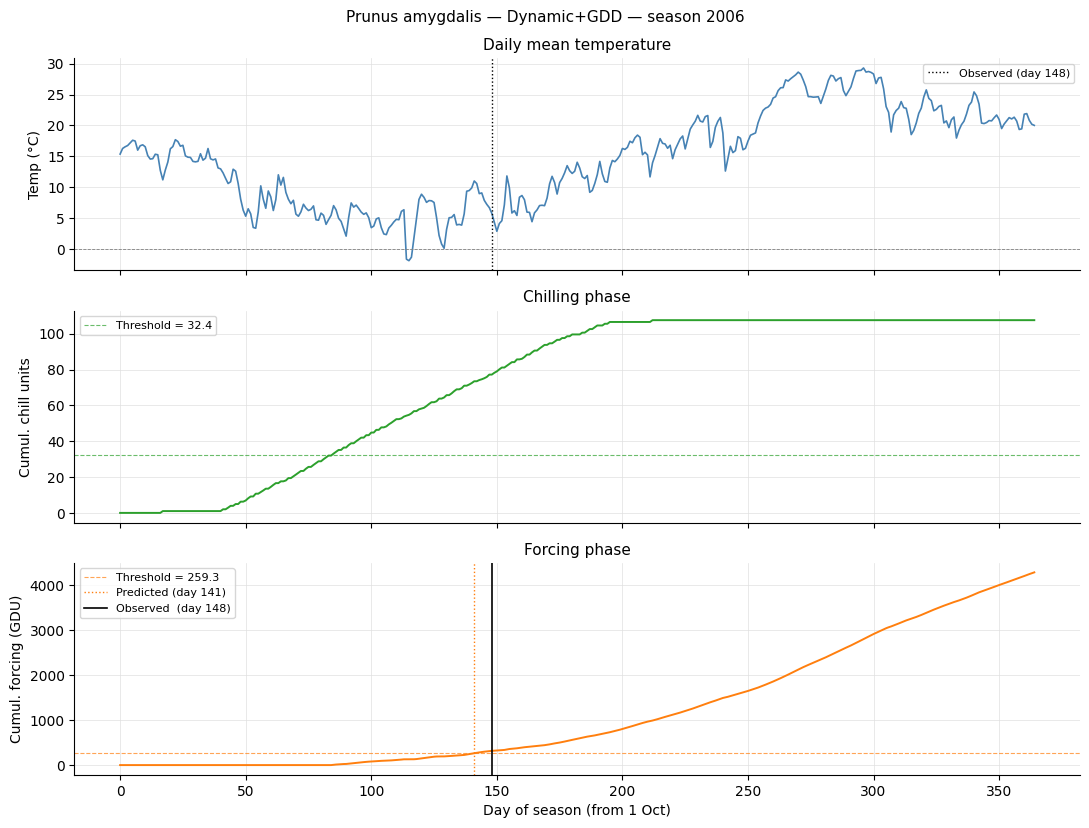

In [13]:
def pick_sample(ds, year=None):
    if year is None:
        year = min(ds.years)
    for item in ds.iter_items():
        if item['year'] == year:
            return item
    raise ValueError(f'No sample found for year {year}')


def compute_model_response(model, sample):
    ts = sample[KEY_FEATURES]['temperature_2m_mean']
    if isinstance(model, (UtahGDDModel, ChillingDaysGDDModel, DynamicGDDModel)):
        cs, fs = model.get_cf_features(sample)
        chill_cs   = np.cumsum(cs)
        chill_gate = (chill_cs >= model.threshold_c).astype(float)
        force_cs   = np.cumsum(fs * chill_gate)
        th_c, th_f = model.threshold_c, model.threshold_f
    else:  # GDDModel
        chill_cs = None
        t_upper  = model.t_upper
        ts_clip  = np.clip(ts, a_min=None, a_max=t_upper) if t_upper else ts
        force_cs = np.clip(ts_clip - model.t_base, 0, None).cumsum()
        th_c, th_f = None, model.threshold
    _, info = model.predict(sample)
    return dict(ts=ts, chill_cs=chill_cs, force_cs=force_cs,
                th_c=th_c, th_f=th_f, ix=info['ix'])


def plot_response(sp_name, model_name, sample):
    model = fitted[sp_name][model_name]
    r     = compute_model_response(model, sample)
    ts    = r['ts']
    days  = np.arange(len(ts))

    obs_date = sample['observations'][OBS_KEY]
    obs_ix   = int((np.datetime64(obs_date, 'D') -
                    np.datetime64(sample['season_start'], 'D')) /
                   np.timedelta64(1, 'D'))

    has_chill = r['chill_cs'] is not None
    nrows = 3 if has_chill else 2

    fig, axes = plt.subplots(nrows, 1, figsize=(11, nrows * 2.8), sharex=True)
    fig.suptitle(f'{sp_name} — {model_name} — season {sample["year"]}', fontsize=11)

    ax = axes[0]
    ax.plot(days, ts, color='steelblue', linewidth=1.2)
    ax.axhline(0, color='grey', linewidth=0.6, linestyle='--')
    ax.axvline(obs_ix, color='black', linewidth=1.0, linestyle=':',
               label=f'Observed (day {obs_ix})')
    ax.set_ylabel('Temp (°C)')
    ax.legend(fontsize=8)
    ax.set_title('Daily mean temperature')

    if has_chill:
        ax = axes[1]
        ax.plot(days, r['chill_cs'], color='C2', linewidth=1.4)
        ax.axhline(r['th_c'], color='C2', linewidth=0.8, linestyle='--', alpha=0.7,
                   label=f'Threshold = {r["th_c"]:.1f}')
        ax.set_ylabel('Cumul. chill units')
        ax.legend(fontsize=8)
        ax.set_title('Chilling phase')

    ax = axes[-1]
    ax.plot(days, r['force_cs'], color='C1', linewidth=1.4)
    ax.axhline(r['th_f'], color='C1', linewidth=0.8, linestyle='--', alpha=0.7,
               label=f'Threshold = {r["th_f"]:.1f}')
    ax.axvline(r['ix'], color='C1', linewidth=1.0, linestyle=':',
               label=f'Predicted (day {r["ix"]})')
    ax.axvline(obs_ix, color='black', linewidth=1.2, linestyle='-',
               label=f'Observed  (day {obs_ix})')
    ax.set_ylabel('Cumul. forcing (GDU)')
    ax.set_xlabel('Day of season (from 1 Oct)')
    ax.legend(fontsize=8)
    ax.set_title('Forcing phase')

    plt.tight_layout()
    return fig


with plt.rc_context({**_STYLE, 'axes.grid': True, 'grid.color': '#e0e0e0',
                     'grid.linewidth': 0.5, 'axes.axisbelow': True}):
    for sp in sp_names:
        mname       = best[sp]
        _, ds_tst   = species_datasets[sp]
        test_year   = min(ds_tst.years) if ds_tst.years else None
        if test_year is None:
            continue
        sample = pick_sample(ds_tst, year=test_year)
        fig    = plot_response(sp, mname, sample)
        plt.show()